In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.optimize import curve_fit

In [2]:
LAMBDA_0 = 658.6 * 1e-9
KB = 1.38 * 1e-23
REFRAC_INDEX = 1.332
TEMP = 23.48
VISCOSITY = 0.927442431 * 1e-3

def q(theta):
    return (4 * np.pi * REFRAC_INDEX * np.sin(theta / 2)) / (LAMBDA_0)

def linear(x, a, b):
    return a*x + b

def stoks_einstein(d, d_err, temp, viscosity):
    d, d_err = d*1e-11, d_err*1e-11
    temp = temp + 273.15
    r_h = (temp * KB)/(6 * np.pi * viscosity * d)
    r_h_err = (temp * KB * d_err)/(6 * np.pi * viscosity * d**2)
    return r_h, r_h_err

In [3]:
au_data = pd.DataFrame({'θ': np.arange(20, 150, 10),
                       '$t_{cor}$, [ms]': np.array([2.782, 1.123, 0.713, 0.453, 0.288, 0.247, 0.183, 0.183, 0.135, 0.135, 0.116, 0.116, 0.100]),
                        '$q \cdot 10^{-7}$, $[m^{-1}]$': q(1e-7 * (np.arange(20, 150, 10) * (np.pi / 180))),
                       '$σ_{t_{cor}}$, [ms]': np.array([0.697, 0.628, 0.151, 0.244, 0.19, 0.122, 0.078, 0.084, 0.031, 0.068, 0.059, 0.049, 0.064]),
                       '$I_{sc}$, a.u.': np.array([546425, 388693, 305426, 252938, 225945, 212611, 196574, 194109, 200594, 202605, 219506, 243375, 280955])})
au_data

,θ,"$t_{cor}$, [ms]","$q \cdot 10^{-7}$, $[m^{-1}]$","$σ_{t_{cor}}$, [ms]","$I_{sc}$, a.u."
0,20,2.782,0.443578,0.697,546425
1,30,1.123,0.665367,0.628,388693
2,40,0.713,0.887155,0.151,305426
3,50,0.453,1.108944,0.244,252938
4,60,0.288,1.330733,0.190,225945
5,70,0.247,1.552522,0.122,212611
6,80,0.183,1.774311,0.078,196574
7,90,0.183,1.996100,0.084,194109
8,100,0.135,2.217889,0.031,200594
9,110,0.135,2.439677,0.068,202605


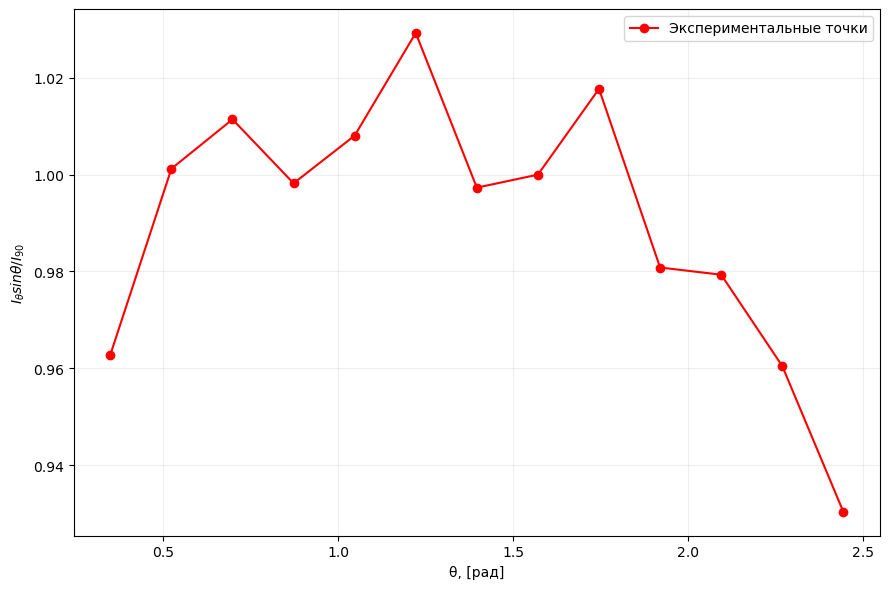

In [4]:
plt.figure(figsize=(9, 6))
plt.plot(au_data['θ'] * (np.pi / 180), np.sin(au_data['θ'] * (np.pi / 180)) * au_data['$I_{sc}$, a.u.'] / 194109, 'r-o', label='Экспериментальные точки')
#plt.plot(-au_data['θ'] * (np.pi / 180), np.sin(au_data['θ'] * (np.pi / 180)) * au_data['$I_{sc}$, a.u.'] / 194109, 'r-^', label='Отраженные точки')
plt.legend()
plt.grid(alpha=0.2)
plt.xlabel('θ, [рад]')
plt.ylabel('$I_{θ}sinθ/I_{90}$')
plt.tight_layout()
plt.show()

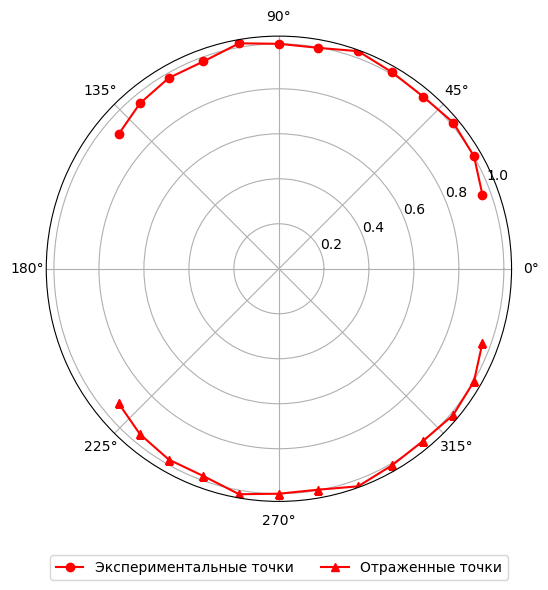

In [5]:
plt.figure(figsize=(6,6))
plt.polar(au_data['θ'] * (np.pi / 180), np.sin(au_data['θ'] * (np.pi / 180)) * au_data['$I_{sc}$, a.u.'] / 194109, 'r-o', label='Экспериментальные точки')
plt.polar(-au_data['θ'] * (np.pi / 180), np.sin(au_data['θ'] * (np.pi / 180)) * au_data['$I_{sc}$, a.u.'] / 194109, 'r-^', label='Отраженные точки')
plt.legend(bbox_to_anchor=(0.5, -0.1), loc='upper center', ncol=2)
plt.tight_layout()
plt.show()

In [6]:
au_q2 = au_data['$q \cdot 10^{-7}$, $[m^{-1}]$']**2
au_tc = au_data["$t_{cor}$, [ms]"]
au_tc_std = au_data['$σ_{t_{cor}}$, [ms]']
au_rev_tcor_err = abs(- 1 / au_tc**2) *  au_tc_std

popt, pcov = curve_fit(linear, au_q2, 1/au_tc)
a_opt_au_full, b_opt_au_full = popt
a_err_au_full, b_err_au_full = np.sqrt(np.diag(pcov))

popt, pcov = curve_fit(linear, au_q2[:8], 1/au_tc[:8])
a_opt_au_cut, b_opt_au_cut = popt
a_err_au_cut, b_err_au_cut = np.sqrt(np.diag(pcov))

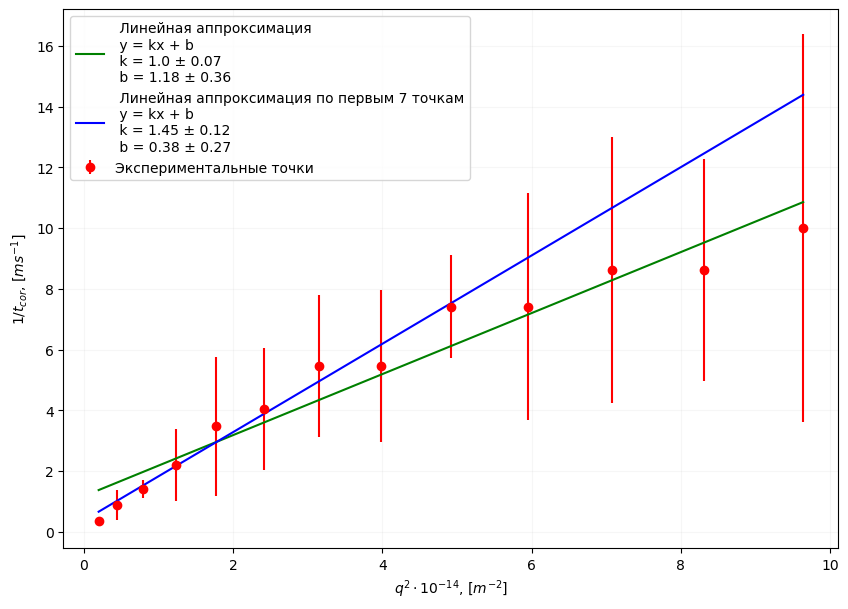

In [6]:
plt.figure(figsize=(10, 7))
plt.errorbar(x=au_q2, y=1/au_tc, yerr=au_rev_tcor_err, fmt='o', c='r', label='Экспериментальные точки')

plt.plot(au_q2, linear(au_q2, a_opt_au_full, b_opt_au_full), c='g', label=f" Линейная аппроксимация\n y = kx + b\n k = {round(a_opt_au_full, 2)} ± {round(a_err_au_full, 2)}\n b = {round(b_opt_au_full, 2)} ± {round(b_err_au_full,2)}")
plt.plot(au_q2, linear(au_q2, a_opt_au_cut, b_opt_au_cut), c='b', label=f' Линейная аппроксимация по первым 7 точкам\n y = kx + b\n k = {round(a_opt_au_cut, 2)} ± {round(a_err_au_cut, 2)}\n b = {round(b_opt_au_cut, 2)} ± {round(b_err_au_cut, 2)}')

plt.grid(alpha=0.1)
plt.xlabel('$q^2\cdot 10^{-14}$, $[m^{-2}]$')
plt.ylabel('$1/t_{cor}$, $[ms^{-1}]$')
plt.legend()
plt.show()

In [7]:
print('=== DIFFUSION ===')

print(f'({round(a_opt_au_full, 2)} ± {round(a_err_au_full, 2)}) * 10^-11, [m^2/s], (for all points)')
print(f'({round(a_opt_au_cut, 2)} ± {round(a_err_au_cut, 2)}) * 10^-11, [m^2/s], (for first 7 points)')

=== DIFFUSION ===
(1.0 ± 0.07) * 10^-11, [m^2/s], (for all points)
(1.45 ± 0.12) * 10^-11, [m^2/s], (for first 7 points)


In [8]:
print('=== Hydrodynamic radiuses ===')

r_au_full, r_au_full_err = np.array(stoks_einstein(a_opt_au_full, a_err_au_full, TEMP, VISCOSITY)) * 1e9
r_au_cut, r_au_cut_err = np.array(stoks_einstein(a_opt_au_cut, a_err_au_cut, TEMP, VISCOSITY)) * 1e9

print(f'{r_au_full:.1f} ± {r_au_full_err:.1f} [nm], (for all points)')
print(f'{r_au_cut:.1f} ± {r_au_cut_err:.1f} [nm], (for first 7 points)')

=== Hydrodynamic radiuses ===
23.3 ± 1.7 [nm], (for all points)
16.1 ± 1.4 [nm], (for first 7 points)


In [9]:
s_data = pd.DataFrame({'θ': np.arange(20, 150, 10),
                       '$t_{cor}$, [ms]': np.array([42.34, 17.09, 9.33, 5.094, 3.765, 3.236, 2.056, 2.056, 1.519, 1.306, 1.306, 1.519, 1.767]),
                        '$q \cdot 10^{-7}$, $[m^{-1}]$': q(1e-7 * (np.arange(20, 150, 10) * (np.pi / 180))),
                       '$σ_{t_{cor}}$, [ms]': np.array([11.98, 12.54, 4.133, 1.118, 0.888, 1.377, 0.639, 0.6, 0.391, 0.269, 0.230, 0.378, 0.577]),
                       '$I_{sc}$, a.u.': np.array([710136, 326184, 184990, 115558, 80890, 54537, 43974, 37200, 32157, 30321, 31532, 36984, 46465])})
s_data

,θ,"$t_{cor}$, [ms]","$q \cdot 10^{-7}$, $[m^{-1}]$","$σ_{t_{cor}}$, [ms]","$I_{sc}$, a.u."
0,20,42.340,0.443578,11.980,710136
1,30,17.090,0.665367,12.540,326184
2,40,9.330,0.887155,4.133,184990
3,50,5.094,1.108944,1.118,115558
4,60,3.765,1.330733,0.888,80890
5,70,3.236,1.552522,1.377,54537
6,80,2.056,1.774311,0.639,43974
7,90,2.056,1.996100,0.600,37200
8,100,1.519,2.217889,0.391,32157
9,110,1.306,2.439677,0.269,30321


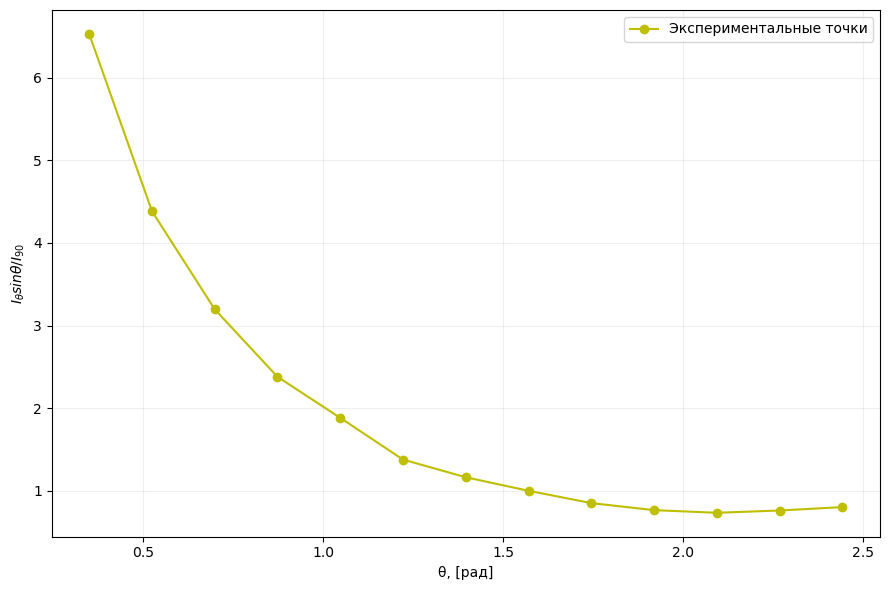

In [10]:
plt.figure(figsize=(9, 6))
plt.plot(s_data['θ'] * (np.pi / 180), np.sin(s_data['θ'] * (np.pi / 180)) * s_data['$I_{sc}$, a.u.'] / 37200, 'y-o', label='Экспериментальные точки')
#plt.polar(-s_data['θ'] * (np.pi / 180), np.sin(s_data['θ'] * (np.pi / 180)) * s_data['$I_{sc}$, a.u.'] / 37200, 'y-^', label='Отраженные точки')
plt.legend()
plt.grid(alpha=0.2)
plt.xlabel('θ, [рад]')
plt.ylabel('$I_{θ}sinθ/I_{90}$')
plt.tight_layout()
plt.show()

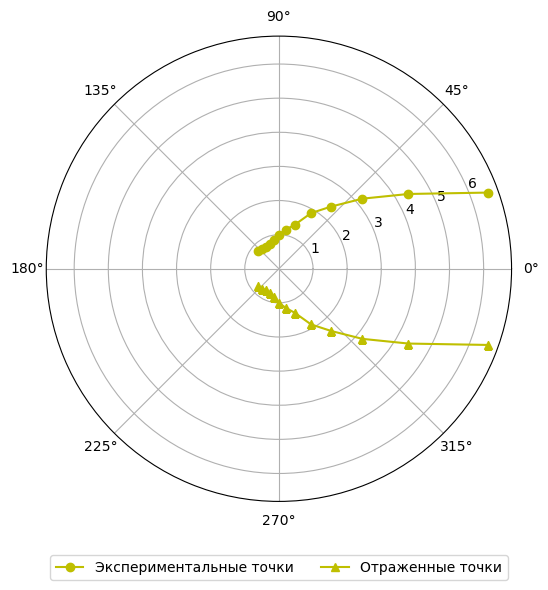

In [11]:
plt.figure(figsize=(6,6))
plt.polar(s_data['θ'] * (np.pi / 180), np.sin(s_data['θ'] * (np.pi / 180)) * s_data['$I_{sc}$, a.u.'] / 37200, 'y-o', label='Экспериментальные точки')
plt.polar(-s_data['θ'] * (np.pi / 180), np.sin(s_data['θ'] * (np.pi / 180)) * s_data['$I_{sc}$, a.u.'] / 37200, 'y-^', label='Отраженные точки')
plt.legend(bbox_to_anchor=(0.5, -0.1), loc='upper center', ncol=2)
plt.tight_layout()
plt.show()

In [12]:
s_q2 = s_data['$q \cdot 10^{-7}$, $[m^{-1}]$']**2
s_tc = s_data["$t_{cor}$, [ms]"]
s_tc_std = s_data['$σ_{t_{cor}}$, [ms]']
s_rev_tcor_err = abs(- 1 / s_tc**2) *  s_tc_std

popt, pcov = curve_fit(linear, s_q2, 1/s_tc)
a_opt_s_full, b_opt_s_full = popt
a_err_s_full, b_err_s_full = np.sqrt(np.diag(pcov))

popt, pcov = curve_fit(linear, s_q2[:8], 1/s_tc[:8])
a_opt_s_cut, b_opt_s_cut = popt
a_err_s_cut, b_err_s_cut = np.sqrt(np.diag(pcov))

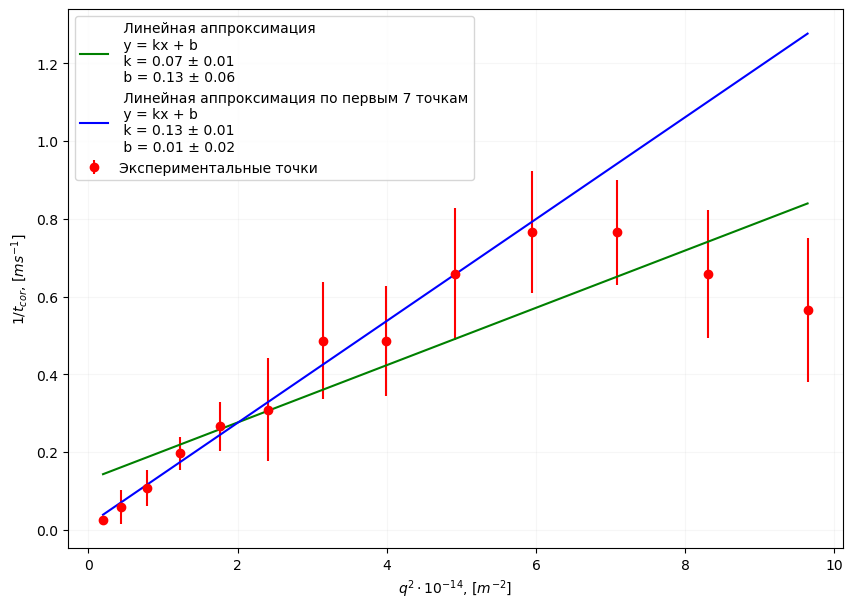

In [13]:
plt.figure(figsize=(10, 7))
plt.errorbar(x=s_q2, y=1/s_tc, yerr=s_rev_tcor_err, fmt='o', c='r', label='Экспериментальные точки')

plt.plot(s_q2, linear(s_q2, a_opt_s_full, b_opt_s_full), c='g', label=f" Линейная аппроксимация\n y = kx + b\n k = {round(a_opt_s_full, 2)} ± {round(a_err_s_full, 2)}\n b = {round(b_opt_s_full, 2)} ± {round(b_err_s_full,2)}")
plt.plot(s_q2, linear(s_q2, a_opt_s_cut, b_opt_s_cut), c='b', label=f' Линейная аппроксимация по первым 7 точкам\n y = kx + b\n k = {round(a_opt_s_cut, 2)} ± {round(a_err_s_cut, 2)}\n b = {round(b_opt_s_cut, 2)} ± {round(b_err_s_cut, 2)}')

plt.grid(alpha=0.1)
plt.xlabel('$q^2\cdot 10^{-14}$, $[m^{-2}]$')
plt.ylabel('$1/t_{cor}$, $[ms^{-1}]$')
plt.legend()
plt.show()

In [14]:
print('=== DIFFUSION ===')

print(f'({round(a_opt_s_full, 2)} ± {round(a_err_s_full, 2)}) * 10^-11, [m^2/s], (for all points)')
print(f'({round(a_opt_s_cut, 2)} ± {round(a_err_s_cut, 2)}) * 10^-11, [m^2/s], (for first 7 points)')

=== DIFFUSION ===
(0.07 ± 0.01) * 10^-11, [m^2/s], (for all points)
(0.13 ± 0.01) * 10^-11, [m^2/s], (for first 7 points)


In [15]:
print('=== Hydrodynamic radiuses ===')

r_s_full, r_s_full_err = np.array(stoks_einstein(a_opt_s_full, a_err_s_full, TEMP, VISCOSITY)) * 1e9
r_s_cut, r_s_cut_err = np.array(stoks_einstein(a_opt_s_cut, a_err_s_cut, TEMP, VISCOSITY)) * 1e9

print(f'{r_s_full:.1f} ± {r_s_full_err:.1f} [nm], (for all points)')
print(f'{r_s_cut:.1f} ± {r_s_cut_err:.1f} [nm], (for first 7 points)')

=== Hydrodynamic radiuses ===
317.4 ± 55.3 [nm], (for all points)
178.6 ± 13.8 [nm], (for first 7 points)


In [16]:
arg = []
acf = []
wt = []

with open('AMG_DLS/!Reading_AU! — копия.txt', 'r') as file:
    for line in file:
        parts = line.strip().split()
        arg_value = float(parts[0].split('=')[1].strip('.'))
        acf_value = float(parts[1].split('=')[1].strip('.'))
        wt_value = float(parts[2].split('=')[1])
        arg.append(arg_value)
        acf.append(acf_value)
        wt.append(wt_value)
        
arg, acf, wt = np.array(arg), np.array(acf), np.array(wt)
n = np.arange(1, 289)

n = n[65:120] 
acf = acf[65:120]
time = 1e-8 * pow(2, n/8)


def exp_func(x, a, b, c):
    return a * np.exp(-b * x) + c

params, cov = curve_fit(exp_func, time, acf, p0=(0.3, 10000, 0.0))
a, b_au, c = params
aerr, berr_au, cerr = np.sqrt(np.diag(cov))

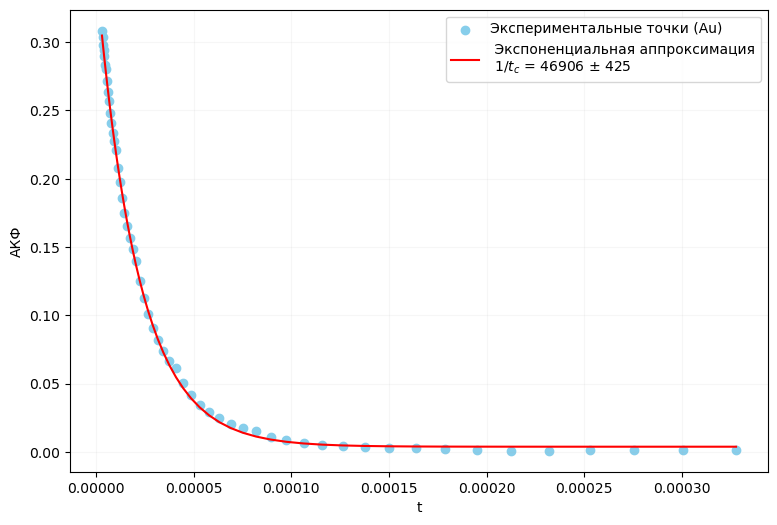

In [17]:
plt.figure(figsize=(9, 6))
plt.scatter(time, acf, c='skyblue', label='Экспериментальные точки (Au)')
plt.plot(time, exp_func(time, *params), c='r', label=f' Экспоненциальная аппроксимация\n $1/t_c$ = {round(b_au)} ± {round(berr_au)}')
plt.ylabel('АКФ')
plt.xlabel('t')
plt.legend()
plt.grid(alpha=0.1)
plt.show()

In [18]:
print('=== AU DIFFUSION ===')
d_au = b_au / q(np.pi/2)**2
d_err_au = berr_au / q(np.pi/2)**2
print(f'({round(d_au * 1e10, 2)} ± {round(d_err_au * 1e10, 2)}) * 10^-10 [m^2/s]')
print('=== AU RADIUS ===')
r_au, r_au_err = np.array(stoks_einstein(d_au * 1e10, d_err_au * 1e10, TEMP, VISCOSITY)) * 1e9
print(f'{round(r_au, 2)} ± {round(r_au_err, 2)} [nm]')

=== AU DIFFUSION ===
(1.45 ± 0.01) * 10^-10 [m^2/s]
=== AU RADIUS ===
16.12 ± 0.15 [nm]


In [19]:
arg = []
acf = []
wt = []

with open('AMG_DLS/!Reading_S! — копия.txt', 'r') as file:
    for line in file:
        parts = line.strip().split()
        arg_value = float(parts[0].split('=')[1].strip('.'))
        acf_value = float(parts[1].split('=')[1].strip('.'))
        wt_value = float(parts[2].split('=')[1])
        arg.append(arg_value)
        acf.append(acf_value)
        wt.append(wt_value)
        
arg, acf, wt = np.array(arg), np.array(acf), np.array(wt)
n = np.arange(1, 289)

n = n[70:150] 
acf = acf[70:150]
time = 1e-8 * pow(2, n/8)


def exp_func(x, a, b, c):
    return a * np.exp(-b * x) + c

params, cov = curve_fit(exp_func, time, acf, p0=(0.3, 10000, 0.0))
a, b_s, c = params
aerr, berr_s, cerr = np.sqrt(np.diag(cov))

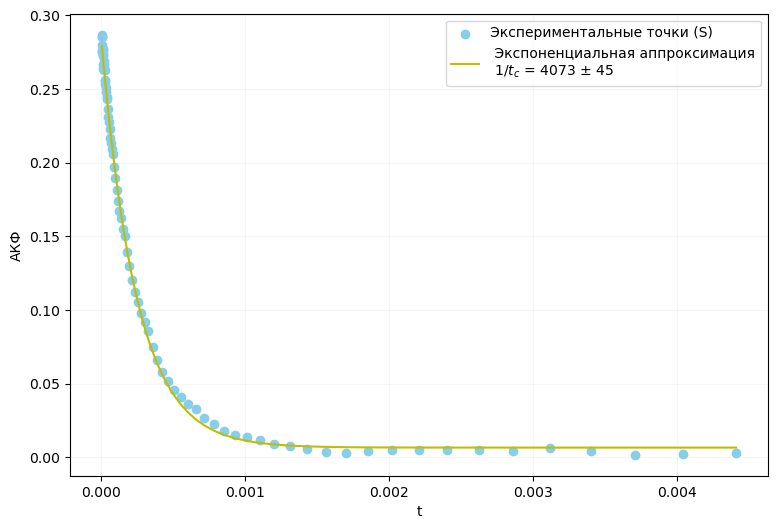

In [212]:
plt.figure(figsize=(9, 6))
plt.scatter(time, acf, c='skyblue', label='Экспериментальные точки (S)')
plt.plot(time, exp_func(time, *params), c='y', label=f' Экспоненциальная аппроксимация\n $1/t_c$ = {round(b_s)} ± {round(berr_s)}')
plt.legend()
plt.ylabel('АКФ')
plt.xlabel('t')
plt.grid(alpha=0.1)
plt.show()

In [20]:
print('=== S DIFFUSION ===')
d_s = b_s / q(np.pi/2)**2
d_err_s = berr_s / q(np.pi/2)**2
print(f'({round(d_s * 1e10, 2)} ± {round(d_err_s * 1e10, 2)}) * 10^-10 [m^2/s]')
print('=== S RADIUS ===')
r_s, r_s_err = np.array(stoks_einstein(d_s * 1e10, d_err_s * 1e10, TEMP, VISCOSITY)) * 1e9
print(f'{round(r_s, 2)} ± {round(r_s_err, 2)} [nm]')

=== S DIFFUSION ===
(0.13 ± 0.0) * 10^-10 [m^2/s]
=== S RADIUS ===
185.67 ± 2.06 [nm]
